# Zomato Restaurant Segmentation using K-Means Clustering
### An Unsupervised Machine Learning Project — AI/ML Intern



## Problem Statement

1. Zomato has thousands of restaurants with different **prices, cuisines, ratings, and popularity**.

2. It is difficult to analyze and manage restaurants **individually** due to the large amount of data.

3. There are **no predefined categories or labels** for grouping similar restaurants.

4. **K-Means Clustering**, an unsupervised learning algorithm, can be used to identify natural restaurant groups.

5. These groups can help Zomato and restaurant owners improve **pricing, marketing, customer targeting, and business strategies**.


## Project Summary

We use two real datasets:
1. **Restaurant Names and Metadata** — 105 restaurants, with cost, cuisines, collections
   (curated Zomato tags), and timings.
2. **Restaurant Reviews** — ~10,000 customer reviews across 100 of those restaurants, with
   star ratings, review text, reviewer info, and photo counts.

We will merge these two datasets, clean them, engineer restaurant-level features from the
review data, and cluster the restaurants using K-Means — choosing the number of clusters
using the **Elbow Method** and **Silhouette Score**. We'll then profile each cluster in plain
business terms and give concrete recommendations.
*"I grouped restaurants into natural
segments based on price, cuisine variety, and how customers rate/engage with them — without
being told in advance what the groups should be."*


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports and Setup

We import:
- `pandas`/`numpy` for data handling
- `matplotlib`/`seaborn` for visualization
- `scikit-learn` for scaling, encoding, and K-Means clustering
- `re` for parsing text fields (e.g. pulling numbers out of `"3 Reviews , 2 Followers"`)


In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import pickle

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

pd.set_option('display.max_columns', None)
print("Libraries loaded.")

Libraries loaded.


## 2. Load the Datasets

We load both CSV files exactly as provided — no assumptions about their structure yet.


In [ ]:
meta = pd.read_csv('Zomato Restaurant names and Metadata.csv')
reviews = pd.read_csv('Zomato Restaurant reviews.csv')

print("Metadata shape:", meta.shape)
print("Reviews shape:", reviews.shape)
meta.head(3)

Metadata shape: (105, 6)
Reviews shape: (10000, 7)


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"


In [ ]:
reviews.head(3)

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0


## 3. Inspect Both Datasets

**Why we do this first:** before touching the data, we need to know exactly what we're
working with — column types, how much is missing, and whether there are duplicates. Skipping
this step is how people accidentally build models on broken data.


In [ ]:
print("=== METADATA: dtypes ===")
print(meta.dtypes)
print("\n=== METADATA: missing values ===")
print(meta.isnull().sum())
print("\n=== METADATA: duplicate rows ===", meta.duplicated().sum())
print("=== METADATA: duplicate restaurant names ===", meta['Name'].duplicated().sum())

=== METADATA: dtypes ===
Name           object
Links          object
Cost           object
Collections    object
Cuisines       object
Timings        object
dtype: object

=== METADATA: missing values ===
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64

=== METADATA: duplicate rows === 0
=== METADATA: duplicate restaurant names === 0


In [ ]:
print("=== REVIEWS: dtypes ===")
print(reviews.dtypes)
print("\n=== REVIEWS: missing values ===")
print(reviews.isnull().sum())
print("\n=== REVIEWS: duplicate rows ===", reviews.duplicated().sum())
print("=== REVIEWS: unique restaurants ===", reviews['Restaurant'].nunique())

=== REVIEWS: dtypes ===
Restaurant    object
Reviewer      object
Review        object
Rating        object
Metadata      object
Time          object
Pictures       int64
dtype: object

=== REVIEWS: missing values ===
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64

=== REVIEWS: duplicate rows === 36
=== REVIEWS: unique restaurants === 100


**What we found:**
- Metadata has 105 restaurants, all with unique names. `Collections` is missing for about
  half the restaurants (many restaurants simply aren't featured in any curated Zomato list —
  this is a genuine "no collection" case, not a data error).
- Reviews has 10,000 rows across only 100 restaurants (so 5 metadata restaurants have **no
  reviews at all**), plus 36 fully-blank duplicate rows and a handful of nulls, which look like
  corrupted/empty review entries rather than real data.
- `Rating` is stored as **text**, not a number, and includes one non-numeric value (`'Like'`)
  — a UI artifact from Zomato, not an actual star rating. We'll treat it as missing.
- `Cost` in the metadata is text with thousand-separator commas (e.g. `"1,300"`) and needs to
  be converted to a number before we can use it.


## 4. Data Cleaning — Metadata

**What we're doing:** converting `Cost` to a proper number, and turning the comma-separated
`Cuisines`/`Collections` text into a count we can use as a feature later (breadth of menu,
and how many curated Zomato lists a restaurant appears in).

**Why:** raw text can't be fed into scaling or K-Means — everything needs to end up numeric.


In [ ]:
meta_clean = meta.copy()

# Cost: remove commas, convert to float
meta_clean['Cost'] = meta_clean['Cost'].astype(str).str.replace(',', '').astype(float)

# Number of cuisines offered (menu breadth)
meta_clean['num_cuisines'] = meta_clean['Cuisines'].apply(lambda x: len(str(x).split(',')))

# Number of curated Zomato "Collections" a restaurant appears in (0 if none)
meta_clean['num_collections'] = meta_clean['Collections'].apply(
    lambda x: 0 if pd.isna(x) else len(str(x).split(','))
)

meta_clean[['Name', 'Cost', 'num_cuisines', 'num_collections']].head()

,Name,Cost,num_cuisines,num_collections
0,Beyond Flavours,800.0,6,6
1,Paradise,800.0,3,1
2,Flechazo,1300.0,4,2
3,Shah Ghouse Hotel & Restaurant,800.0,5,1
4,Over The Moon Brew Company,1200.0,5,5


## 5. Data Cleaning — Reviews

**What we're doing:**
1. Dropping the 36 fully-blank rows (no reviewer, no review text, no rating — nothing to
   analyze).
2. Converting `Rating` to a proper number, turning the one `'Like'` value into a missing
   value (`NaN`) since it isn't a star rating.
3. Parsing the reviewer's own `Metadata` field (e.g. `"3 Reviews , 2 Followers"`) into two
   numeric columns using a regular expression. This describes the **reviewer**, not the
   restaurant — we'll keep it separate and only use it cautiously.
4. Parsing `Time` into an actual datetime.

**Why:** we can't average or plot text. Every downstream step needs clean numeric columns.


In [ ]:
reviews_clean = reviews.dropna(subset=['Reviewer', 'Review', 'Rating'], how='all').copy()
print("Rows before:", reviews.shape[0], "| after dropping blank rows:", reviews_clean.shape[0])

# Rating -> numeric ('Like' becomes NaN automatically)
reviews_clean['Rating'] = pd.to_numeric(reviews_clean['Rating'], errors='coerce')
print("Missing ratings after conversion:", reviews_clean['Rating'].isna().sum())

# Parse reviewer's review/follower counts out of the Metadata text field
def parse_reviewer_meta(text):
    if pd.isna(text):
        return pd.Series([np.nan, np.nan])
    reviews_match = re.search(r'([\d,]+)\s*Reviews?', text)
    followers_match = re.search(r'([\d,]+)\s*Followers?', text)
    n_reviews = int(reviews_match.group(1).replace(',', '')) if reviews_match else np.nan
    n_followers = int(followers_match.group(1).replace(',', '')) if followers_match else np.nan
    return pd.Series([n_reviews, n_followers])

reviews_clean[['reviewer_num_reviews', 'reviewer_num_followers']] = reviews_clean['Metadata'].apply(parse_reviewer_meta)

# Time -> datetime
reviews_clean['Time'] = pd.to_datetime(reviews_clean['Time'], errors='coerce')

reviews_clean[['Restaurant', 'Rating', 'reviewer_num_reviews', 'reviewer_num_followers', 'Time']].head()

Rows before: 10000 | after dropping blank rows: 9962
Missing ratings after conversion: 1


,Restaurant,Rating,reviewer_num_reviews,reviewer_num_followers,Time
0,Beyond Flavours,5.0,1.0,2.0,2019-05-25 15:54:00
1,Beyond Flavours,5.0,3.0,2.0,2019-05-25 14:20:00
2,Beyond Flavours,5.0,2.0,3.0,2019-05-24 22:54:00
3,Beyond Flavours,5.0,1.0,1.0,2019-05-24 22:11:00
4,Beyond Flavours,5.0,3.0,2.0,2019-05-24 21:37:00


## 6. Choosing the Merge Key

The two datasets share restaurant identity through `Name` (metadata) and `Restaurant`
(reviews) — both are the restaurant's name as text. There's no numeric ID in either file, so
**restaurant name is the only usable, and appropriate, merge key.**

We confirmed:
- Every restaurant name in the **reviews** file also appears in the **metadata** file.
- **5 restaurants** in the metadata file have **no matching reviews**: *Wich Please, Republic
  Of Noodles - Lemon Tree Hotel, Angaara Counts 3, IndiBlaze, Sweet Basket*.

**Decision:** use a **left join** (metadata as the base, reviews aggregated on top), so we
keep all 105 restaurants. The 5 with no reviews will simply have missing review-based
features — we'll handle that explicitly rather than silently dropping real restaurants from
the clustering.


## 7. Feature Engineering — From Reviews to Restaurant-Level Features

The reviews file is one row *per review*, but we want to cluster **restaurants**, not
reviews. So we aggregate all reviews for each restaurant into a handful of summary numbers:

- `avg_rating` — average star rating customers gave this restaurant (satisfaction)
- `rating_std` — how much ratings vary (a high value means very mixed/polarizing experiences)
- `avg_pictures` — average number of photos per review (a proxy for how visually engaging /
  "shareable" the experience is)
- `avg_reviewer_followers` — average follower count of the people who reviewed it (kept
  separate/optional — this describes reviewers, not the restaurant)

**Note on review volume:** we checked review *counts* per restaurant, and 98 of the 100
reviewed restaurants have exactly 100 reviews each (the dataset was sampled uniformly). This
means review count carries almost no information here and would be misleading if used as a
"popularity" feature — so we deliberately leave it out of clustering.


In [ ]:
restaurant_features = reviews_clean.groupby('Restaurant').agg(
    avg_rating=('Rating', 'mean'),
    rating_std=('Rating', 'std'),
    avg_pictures=('Pictures', 'mean'),
    avg_reviewer_followers=('reviewer_num_followers', 'mean')
).reset_index()

restaurant_features.rename(columns={'Restaurant': 'Name'}, inplace=True)
restaurant_features.head()

,Name,avg_rating,rating_std,avg_pictures,avg_reviewer_followers
0,10 Downing Street,3.80,1.091751,1.05,261.414894
1,13 Dhaba,3.48,1.566570,0.41,114.280000
2,"3B's - Buddies, Bar & Barbecue",4.76,0.830237,0.13,17.278351
3,AB's - Absolute Barbecues,4.88,0.498077,0.24,10.600000
4,Absolute Sizzlers,3.62,1.581330,0.45,225.369863


## 8. Merging the Datasets

We left-join `meta_clean` (105 restaurants) with `restaurant_features` (100 restaurants) on
`Name`, as decided above. This keeps every restaurant; the 5 without reviews will have `NaN`
in the review-based columns, which we handle next.


In [ ]:
df = meta_clean.merge(restaurant_features, on='Name', how='left')
print("Merged shape:", df.shape)
print("\nMissing values after merge:")
print(df.isnull().sum())
df.head()

Merged shape: (105, 12)

Missing values after merge:
Name                       0
Links                      0
Cost                       0
Collections               54
Cuisines                   0
Timings                    1
num_cuisines               0
num_collections            0
avg_rating                 5
rating_std                 5
avg_pictures               5
avg_reviewer_followers     5
dtype: int64


,Name,Links,Cost,Collections,Cuisines,Timings,num_cuisines,num_collections,avg_rating,rating_std,avg_pictures,avg_reviewer_followers
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6,6,4.28,1.239746,0.39,134.146667
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800.0,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,3,1,4.70,0.771984,0.02,9.279070
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,1300.0,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",4,2,4.66,0.878704,0.55,40.411765
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800.0,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM,5,1,3.21,1.603626,0.30,155.828947
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,1200.0,"Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...",5,5,4.34,1.065719,0.44,73.020833


In [ ]:
# Which restaurants have no review data?
df[df['avg_rating'].isnull()][['Name', 'Cost', 'num_cuisines']]

,Name,Cost,num_cuisines
100,IndiBlaze,600.0,2
101,Sweet Basket,200.0,2
102,Angaara Counts 3,500.0,3
103,Wich Please,250.0,1
104,Republic Of Noodles - Lemon Tree Hotel,1700.0,4


## 9. Handling Missing Values and Outliers

**Missing values — decisions and reasoning:**
- `avg_rating`, `rating_std`, `avg_pictures`, `avg_reviewer_followers`: missing only for the 5
  restaurants with zero reviews. We add a flag column `has_reviews` (0/1) so this information
  isn't silently lost, then fill the missing values with the **median** of each column (median
  is robust to outliers, unlike the mean). This lets these 5 restaurants stay in the clustering
  instead of being dropped.
- `rating_std` can also be `NaN` for restaurants with only 1 valid rating (no variation to
  measure) — filled the same way.
- `Collections` / `num_collections`: a missing `Collections` value genuinely means "not
  featured in any collection," which we already encoded as `num_collections = 0` — no further
  action needed.
- `Timings`: 1 missing value, not used as a clustering feature, so we leave it as-is.

**Outliers:** we check `Cost` for extreme values, since price is naturally skewed (a few very
expensive restaurants). We use the IQR method to spot outliers but **do not remove them** —
an expensive fine-dining restaurant is a real, meaningful restaurant, not a data error, and
K-Means with scaled features can still handle a reasonable spread. We simply confirm nothing
looks like a data-entry mistake (e.g. cost of 0 or negative).


In [ ]:
df['has_reviews'] = df['avg_rating'].notnull().astype(int)

for col in ['avg_rating', 'rating_std', 'avg_pictures', 'avg_reviewer_followers']:
    df[col] = df[col].fillna(df[col].median())

print("Remaining missing values in engineered columns:")
print(df[['avg_rating', 'rating_std', 'avg_pictures', 'avg_reviewer_followers', 'has_reviews']].isnull().sum())

Remaining missing values in engineered columns:
avg_rating                0
rating_std                0
avg_pictures              0
avg_reviewer_followers    0
has_reviews               0
dtype: int64


In [ ]:
Q1 = df['Cost'].quantile(0.25)
Q3 = df['Cost'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df['Cost'] < lower) | (df['Cost'] > upper)]
print(f"Cost IQR bounds: [{lower:.0f}, {upper:.0f}]")
print(f"Number of cost outliers: {len(outliers)}")
outliers[['Name', 'Cost']]

Cost IQR bounds: [-550, 2250]
Number of cost outliers: 2


,Name,Cost
56,Feast - Sheraton Hyderabad Hotel,2500.0
92,Collage - Hyatt Hyderabad Gachibowli,2800.0


These are genuinely expensive restaurants (fine dining), not data errors — we keep them.


## 10. Exploratory Data Analysis (EDA)

We'll now explore the cleaned, merged dataset (`df`, 105 restaurants) with **univariate**,
**bivariate**, and **multivariate** visualizations. For each chart: why we picked it, what it
shows, and whether the insight is useful for the business.

### 10.1 Univariate Analysis


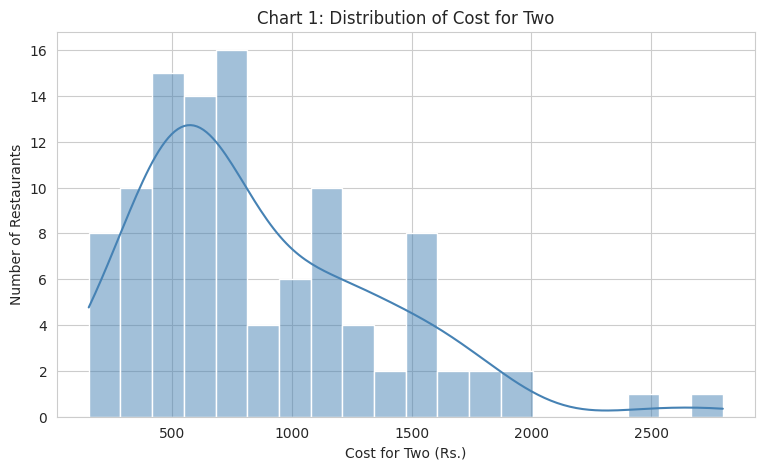

In [ ]:
plt.figure()
sns.histplot(df['Cost'], bins=20, kde=True, color='steelblue')
plt.title('Chart 1: Distribution of Cost for Two')
plt.xlabel('Cost for Two (Rs.)')
plt.ylabel('Number of Restaurants')
plt.show()

**Why this chart:** cost is one of the most important business levers for a restaurant.
**Insight:** most restaurants cluster in the affordable-to-mid range, with a long tail of
premium/fine-dining places — a right-skewed distribution typical of restaurant pricing.
**Business impact:** confirms cost should be scaled (not used raw) before clustering, since
its spread is much larger than rating or cuisine count.


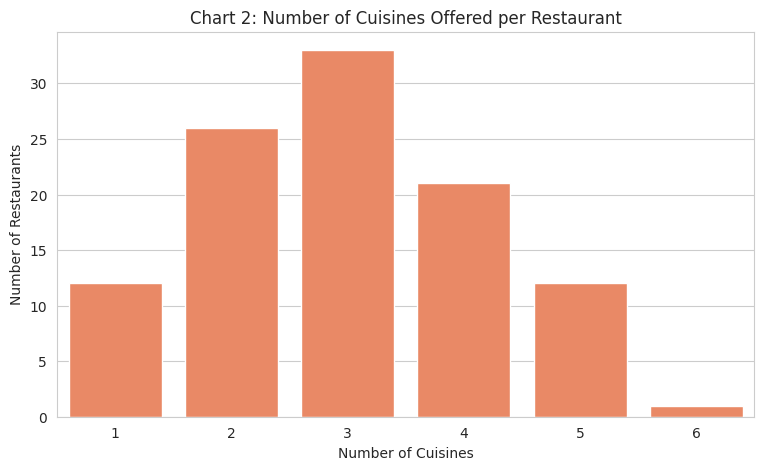

In [ ]:
plt.figure()
sns.countplot(x='num_cuisines', data=df, color='coral')
plt.title('Chart 2: Number of Cuisines Offered per Restaurant')
plt.xlabel('Number of Cuisines')
plt.ylabel('Number of Restaurants')
plt.show()

**Why:** menu breadth is a strategic choice (specialist vs. generalist).
**Insight:** most restaurants offer 2-4 cuisines; very few are single-cuisine specialists or
6-cuisine generalists.
**Business impact:** a restaurant offering many cuisines may be trying to appeal broadly —
useful to see if that correlates with rating later.


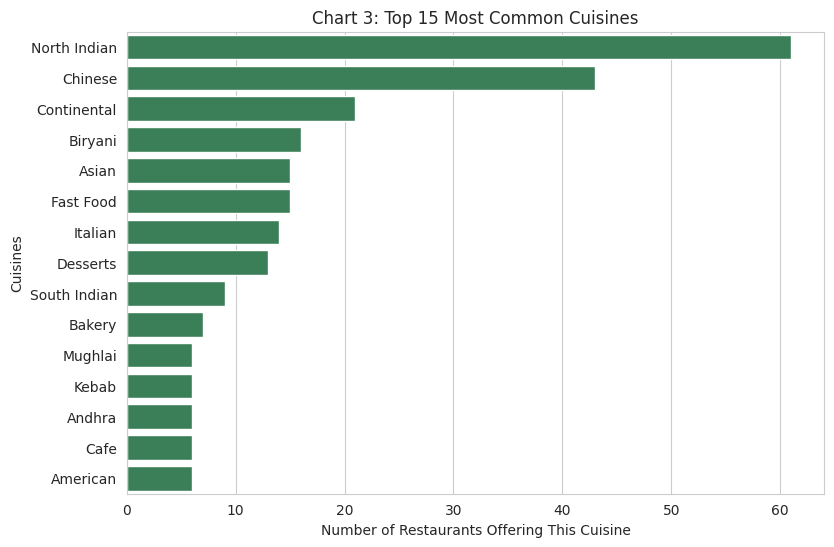

In [ ]:
top_cuisines = df['Cuisines'].str.split(',').explode().str.strip().value_counts().head(15)
plt.figure(figsize=(9,6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, color='seagreen')
plt.title('Chart 3: Top 15 Most Common Cuisines')
plt.xlabel('Number of Restaurants Offering This Cuisine')
plt.show()

**Why:** shows which cuisines dominate this restaurant landscape.
**Insight:** North Indian and Chinese dominate by a wide margin — expected for this market —
followed by Continental and Biryani.
**Business impact:** heavy concentration in a few cuisines means differentiation on cuisine
alone is hard; other factors (price, quality, ambience) likely separate restaurants more than
cuisine type does.


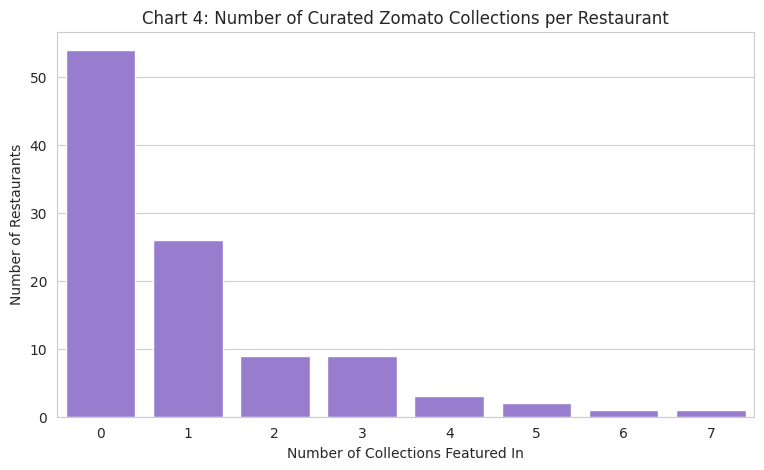

In [ ]:
plt.figure()
sns.countplot(x='num_collections', data=df, color='mediumpurple')
plt.title('Chart 4: Number of Curated Zomato Collections per Restaurant')
plt.xlabel('Number of Collections Featured In')
plt.ylabel('Number of Restaurants')
plt.show()

**Why:** being featured in Zomato's curated collections is itself a popularity/visibility
signal, independent of customer ratings.
**Insight:** about half of restaurants aren't featured in any collection, while a small number
appear in several — a classic popularity skew (a few restaurants get most of the spotlight).
**Business impact (negative angle):** restaurants that never appear in a collection may be
losing organic discovery on the platform regardless of food quality — worth flagging to
Zomato's curation team as a possible visibility gap.


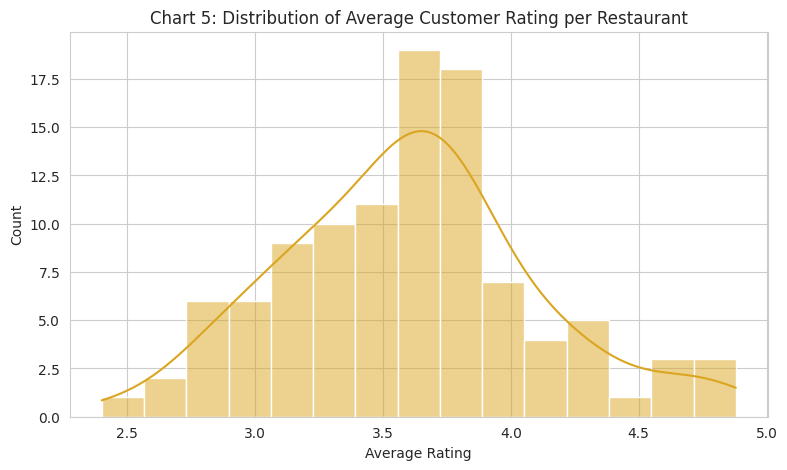

In [ ]:
plt.figure()
sns.histplot(df['avg_rating'], bins=15, kde=True, color='goldenrod')
plt.title('Chart 5: Distribution of Average Customer Rating per Restaurant')
plt.xlabel('Average Rating')
plt.show()

**Why:** average rating is the clearest satisfaction signal we have per restaurant.
**Insight:** most restaurants average between roughly 3 and 4.5 — genuinely poor (<2.5) or
perfect (5.0) averages are rare once you aggregate many reviews.
**Business impact:** a tight rating band means rating alone won't separate restaurants well —
we'll need other features (cost, consistency, cuisine) to find meaningful segments.


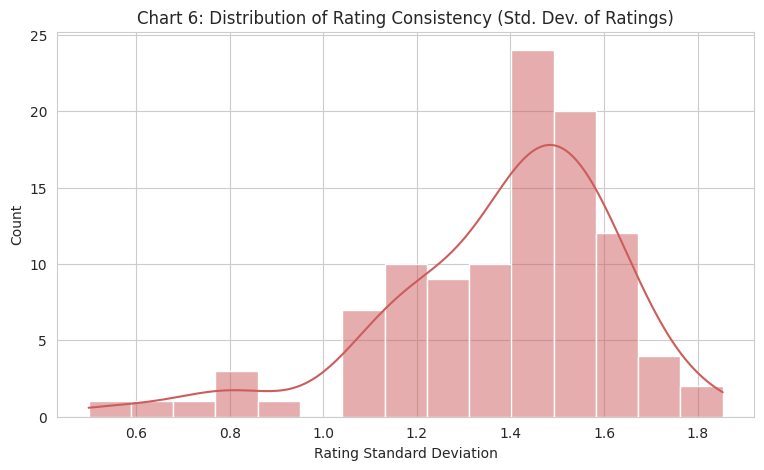

In [ ]:
plt.figure()
sns.histplot(df['rating_std'], bins=15, kde=True, color='indianred')
plt.title('Chart 6: Distribution of Rating Consistency (Std. Dev. of Ratings)')
plt.xlabel('Rating Standard Deviation')
plt.show()

**Why:** two restaurants can have the same *average* rating but very different consistency
— one could be reliably "good," the other wildly inconsistent.
**Insight:** there's a real spread here — some restaurants have tight, consistent ratings,
others are much more polarizing.
**Business impact:** high-variance restaurants are a risk signal (inconsistent experience) even
if their average looks fine — useful for operational quality flags.


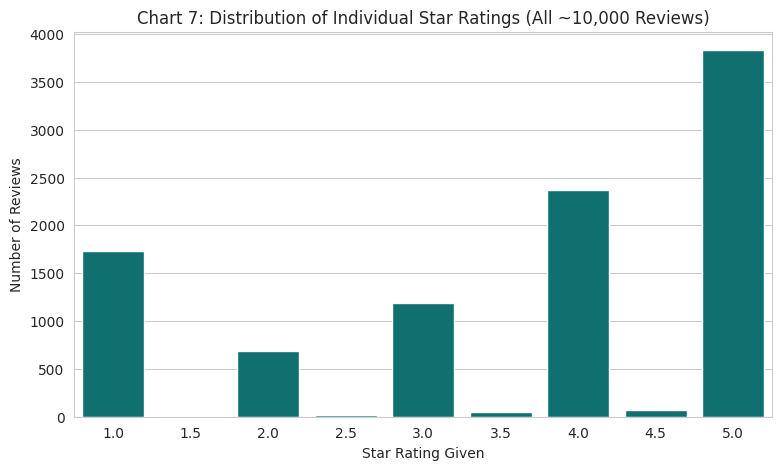

In [ ]:
plt.figure()
sns.countplot(x='Rating', data=reviews_clean, order=sorted(reviews_clean['Rating'].dropna().unique()), color='teal')
plt.title('Chart 7: Distribution of Individual Star Ratings (All ~10,000 Reviews)')
plt.xlabel('Star Rating Given')
plt.ylabel('Number of Reviews')
plt.show()

**Why:** looking at the raw, review-level rating distribution (not averaged) shows patterns in customer rating behavior that averages can hide.
**Insight:** ratings are heavily bimodal — a large share of 5s and 4s, but also a substantial
chunk of 1s, with far fewer 2s and 3s. Customers tend to either love or dislike an experience,
rather than feel lukewarm about it.
**Business impact:** this "love it or hate it" pattern suggests restaurant experience quality
is inconsistent at the point of service — reinforces why `rating_std` (Chart 6) is a useful
feature.


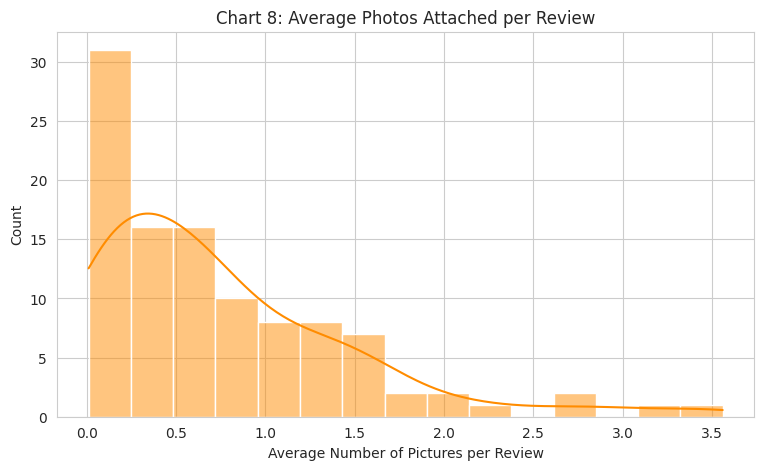

In [ ]:
plt.figure()
sns.histplot(df['avg_pictures'], bins=15, kde=True, color='darkorange')
plt.title('Chart 8: Average Photos Attached per Review')
plt.xlabel('Average Number of Pictures per Review')
plt.show()

**Why:** customers posting photos is a proxy for how visually appealing or "share-worthy" a
restaurant is — a soft popularity/engagement signal distinct from star rating.
**Insight:** most restaurants get very few photos per review on average, with a small number
that are clearly more "photogenic" or Instagram-worthy.
**Business impact:** restaurants with high photo engagement may benefit more from
visual-marketing pushes (Zomato photo campaigns, influencer visits) than others.


### 10.2 Bivariate Analysis

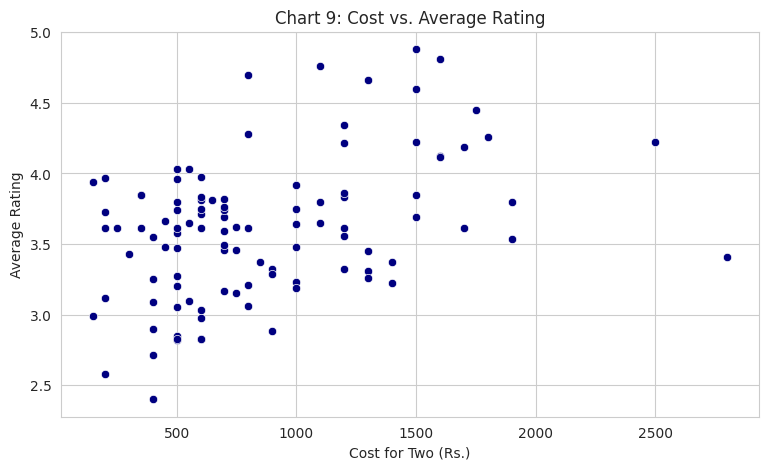

Correlation: 0.41


In [ ]:
plt.figure()
sns.scatterplot(x='Cost', y='avg_rating', data=df, color='navy')
plt.title('Chart 9: Cost vs. Average Rating')
plt.xlabel('Cost for Two (Rs.)')
plt.ylabel('Average Rating')
plt.show()
print("Correlation:", round(df['Cost'].corr(df['avg_rating']), 2))

**Why:** the classic "do you get what you pay for" question.
**Insight:** correlation is +0.41 — a moderate positive relationship. More expensive
restaurants tend to rate somewhat higher, but it's far from a guarantee (plenty of overlap).
**Business impact:** price alone doesn't determine satisfaction — a budget restaurant can
still be excellent, and this is genuinely useful for a "hidden gem" marketing angle.


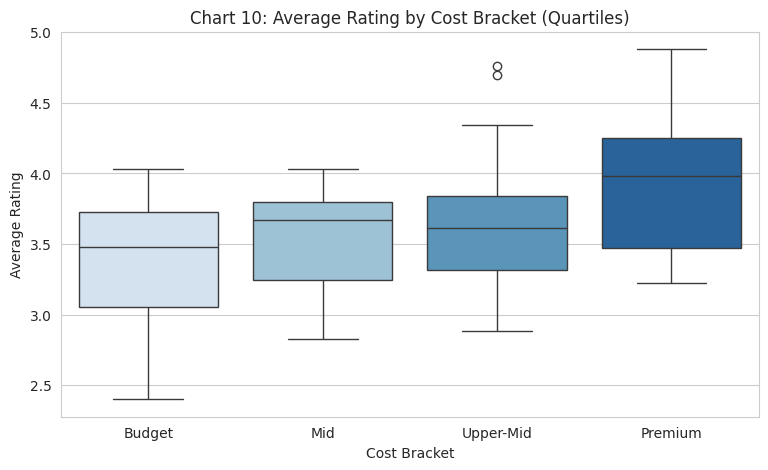

cost_bucket
Budget       3.38
Mid          3.53
Upper-Mid    3.65
Premium      3.96
Name: avg_rating, dtype: float64


In [ ]:
df['cost_bucket'] = pd.qcut(df['Cost'], 4, labels=['Budget', 'Mid', 'Upper-Mid', 'Premium'])
plt.figure()
sns.boxplot(x='cost_bucket', y='avg_rating', data=df, palette='Blues')
plt.title('Chart 10: Average Rating by Cost Bracket (Quartiles)')
plt.xlabel('Cost Bracket')
plt.ylabel('Average Rating')
plt.show()
print(df.groupby('cost_bucket')['avg_rating'].mean().round(2))

**Why:** bucketing cost into quartiles makes the price-vs-quality relationship easier to read
than a raw scatter.
**Insight:** average rating rises fairly steadily from Budget (3.38) to Premium (3.96) —
confirms the moderate positive trend from Chart 9 in a business-friendly format.
**Business impact:** useful for setting customer expectations by price tier, and for premium
restaurants to justify their pricing with genuinely higher-rated experiences.


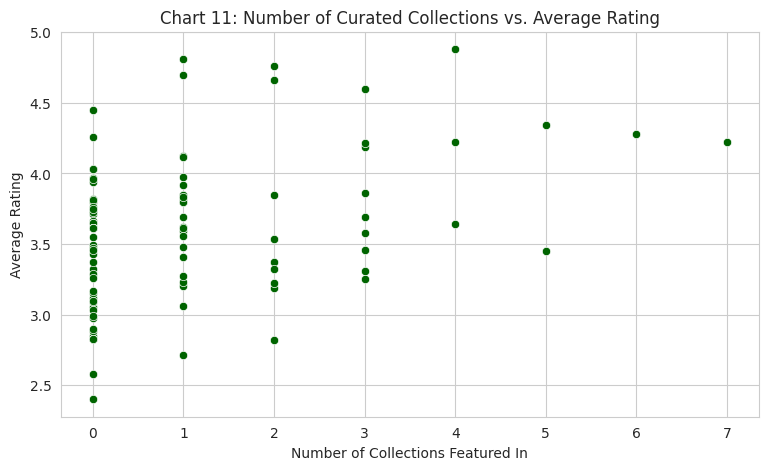

Correlation: 0.36


In [ ]:
plt.figure()
sns.scatterplot(x='num_collections', y='avg_rating', data=df, color='darkgreen')
plt.title('Chart 11: Number of Curated Collections vs. Average Rating')
plt.xlabel('Number of Collections Featured In')
plt.ylabel('Average Rating')
plt.show()
print("Correlation:", round(df['num_collections'].corr(df['avg_rating']), 2))

**Why:** tests whether Zomato's own curation (being featured in collections) lines up with
actual customer satisfaction, or is driven by something else (e.g. marketing/popularity).
**Insight:** correlation is +0.36 — a real but moderate relationship. Being featured is
associated with better ratings, but not strongly enough to say curation is purely
rating-driven.
**Business impact:** worth flagging to Zomato's curation team — factors beyond rating (buzz,
sponsorship, novelty) may be influencing which restaurants get featured.


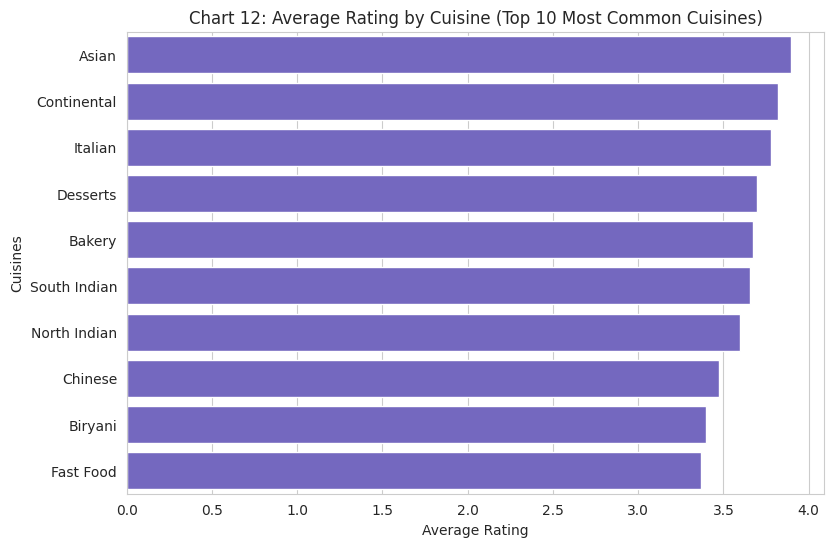

Cuisines
Asian           3.90
Continental     3.82
Italian         3.78
Desserts        3.70
Bakery          3.68
South Indian    3.66
North Indian    3.60
Chinese         3.47
Biryani         3.40
Fast Food       3.37
Name: avg_rating, dtype: float64


In [ ]:
exploded = df[['Name', 'Cuisines', 'avg_rating']].copy()
exploded['Cuisines'] = exploded['Cuisines'].str.split(',')
exploded = exploded.explode('Cuisines')
exploded['Cuisines'] = exploded['Cuisines'].str.strip()

top10_cuisines = exploded['Cuisines'].value_counts().head(10).index
cuisine_rating = (exploded[exploded['Cuisines'].isin(top10_cuisines)]
                   .groupby('Cuisines')['avg_rating'].mean()
                   .sort_values(ascending=False))

plt.figure(figsize=(9, 6))
sns.barplot(x=cuisine_rating.values, y=cuisine_rating.index, color='slateblue')
plt.title('Chart 12: Average Rating by Cuisine (Top 10 Most Common Cuisines)')
plt.xlabel('Average Rating')
plt.show()
print(cuisine_rating.round(2))

**Why:** checks whether cuisine type itself is associated with satisfaction, beyond price.
**Insight:** Asian, Continental, and Italian restaurants average the highest ratings among
common cuisines (~3.8-3.9); Biryani and Fast Food average the lowest (~3.4). This may relate
to these cuisines often being served at higher price points (see Chart 9's cost-rating link)
rather than cuisine itself being "better."
**Business impact:** fast-food/biryani-focused restaurants may need to compete more on
consistency and service, since cuisine type alone doesn't guarantee high ratings.


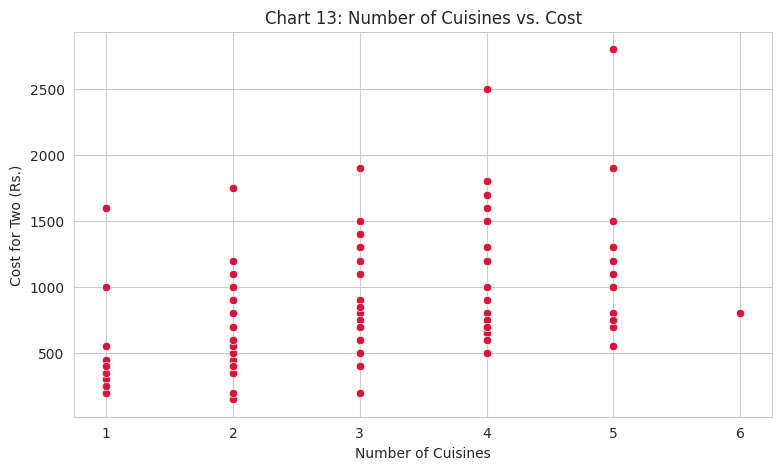

Correlation: 0.41


In [ ]:
plt.figure()
sns.scatterplot(x='num_cuisines', y='Cost', data=df, color='crimson')
plt.title('Chart 13: Number of Cuisines vs. Cost')
plt.xlabel('Number of Cuisines')
plt.ylabel('Cost for Two (Rs.)')
plt.show()
print("Correlation:", round(df['num_cuisines'].corr(df['Cost']), 2))

**Why:** tests whether "menu breadth" and price positioning move together.
**Insight:** correlation of +0.41 — restaurants with more cuisines tend to be somewhat more
expensive, plausibly because a broader menu requires more kitchen capability/inventory.
**Business impact:** a useful sanity check that our features aren't measuring the exact same
underlying thing (which would be redundant for clustering).


### 10.3 Multivariate Analysis

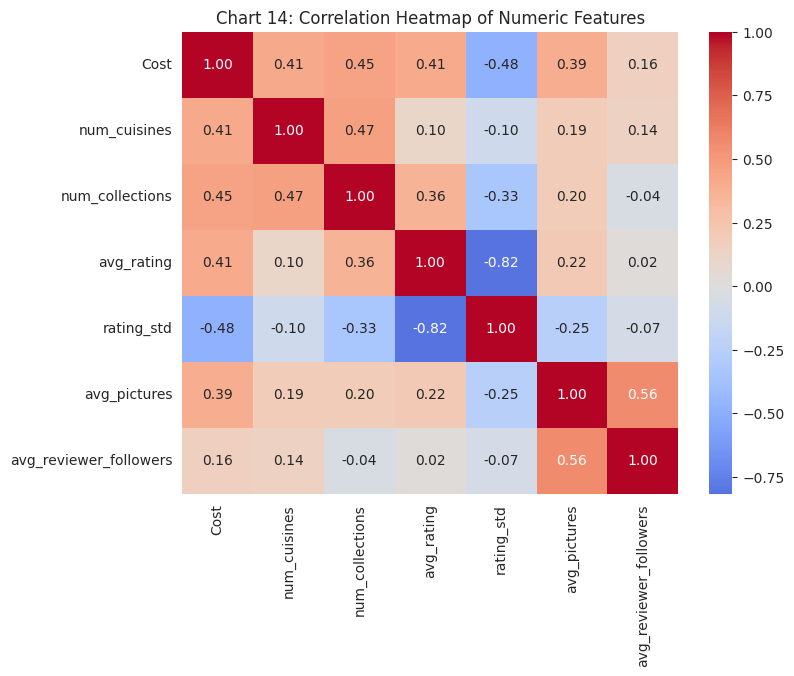

In [ ]:
num_cols = ['Cost', 'num_cuisines', 'num_collections', 'avg_rating',
            'rating_std', 'avg_pictures', 'avg_reviewer_followers']

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Chart 14: Correlation Heatmap of Numeric Features')
plt.show()

**Why:** a single view of how every numeric feature relates to every other — essential before
picking clustering features, so we avoid feeding K-Means two features that are really
measuring the same thing.
**Insight:** the strongest relationships are `Cost` with `num_collections` (+0.45) and
`num_cuisines` (+0.41), and `rating_std` is *negatively* correlated with `Cost` (-0.48) —
pricier restaurants tend to have more *consistent* ratings, not just higher ones.
`avg_reviewer_followers` barely correlates with anything restaurant-related (its strongest
link, +0.56, is with `avg_pictures` — both are reviewer-behavior signals) — supporting our
earlier decision to treat it cautiously.
**Business impact:** premium restaurants deliver a more *predictable* experience — a concrete,
actionable insight for budget/mid-tier restaurants aiming to raise their profile: consistency
may matter as much as raw quality.


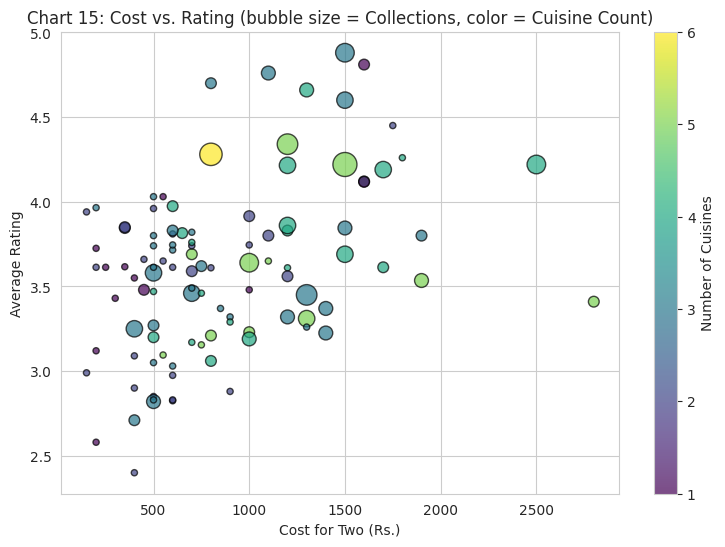

In [ ]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(df['Cost'], df['avg_rating'], s=df['num_collections']*40 + 20,
                       c=df['num_cuisines'], cmap='viridis', alpha=0.7, edgecolor='k')
plt.colorbar(scatter, label='Number of Cuisines')
plt.title('Chart 15: Cost vs. Rating (bubble size = Collections, color = Cuisine Count)')
plt.xlabel('Cost for Two (Rs.)')
plt.ylabel('Average Rating')
plt.show()

**Why:** combines four variables in one chart to see how price, rating, popularity
(collections), and menu breadth interact together, rather than two at a time.
**Insight:** the larger bubbles (more collections) cluster toward the upper-right (higher cost,
higher rating), while small, dark-colored bubbles (few cuisines, cheap) scatter across a wider
rating range — suggesting cheaper, narrow-menu restaurants are the least predictable segment.
**Business impact:** this "least predictable" budget segment is exactly where Zomato/restaurant
owners could get the most lift from quality-consistency initiatives, since the upside (rating)
isn't capped by price positioning.


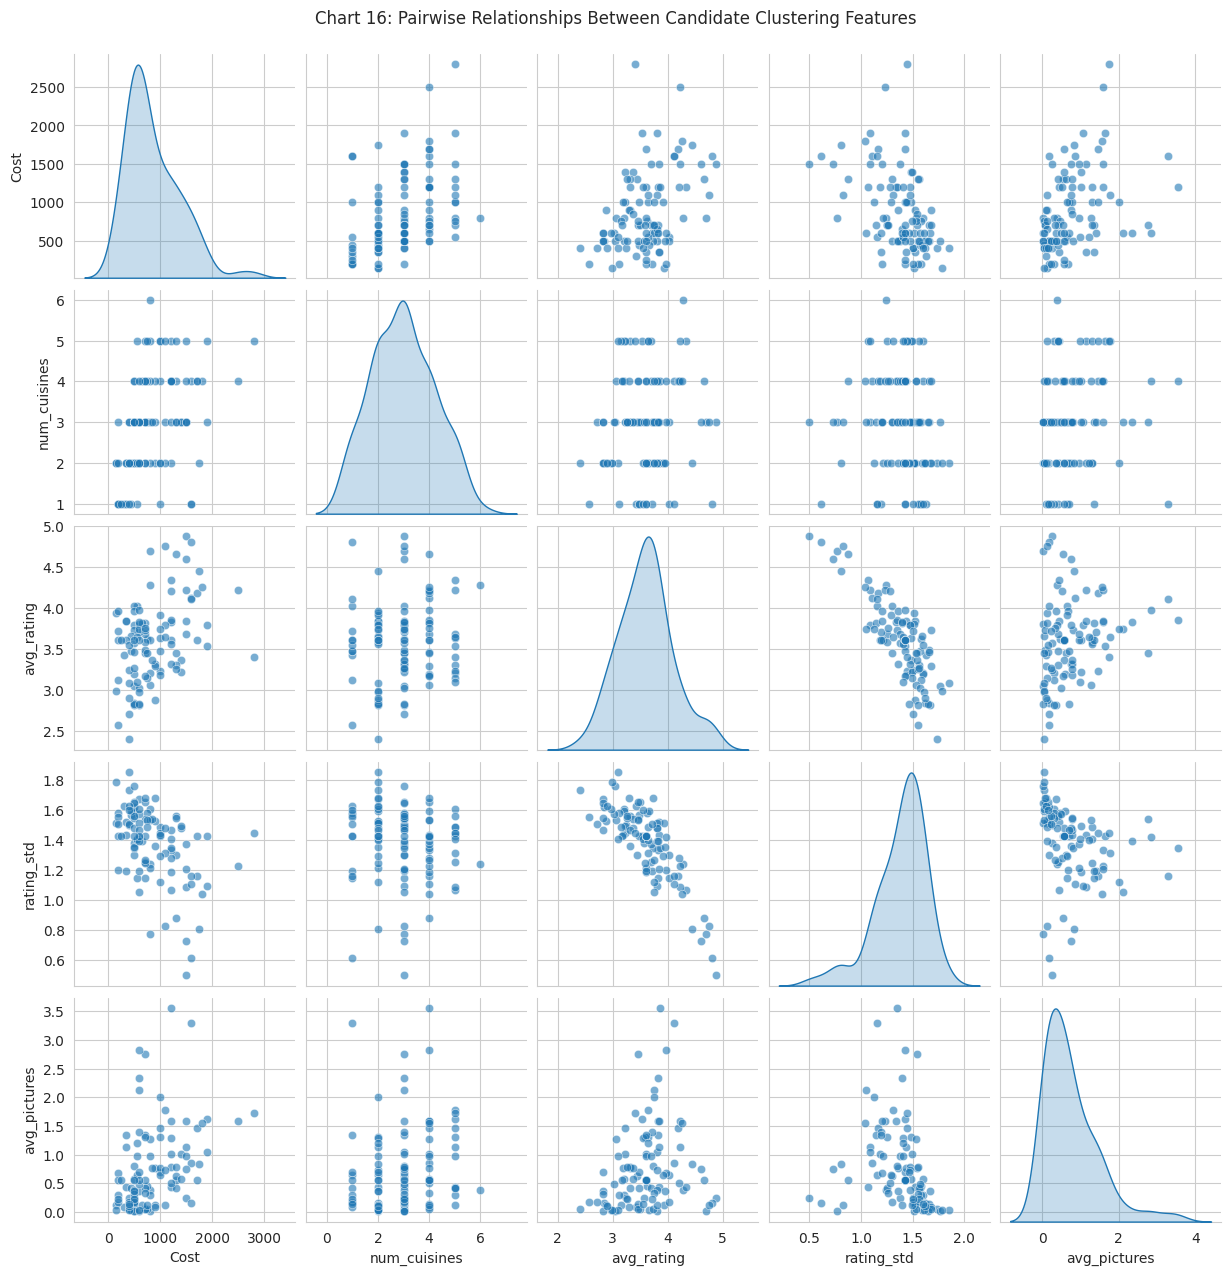

In [ ]:
pairplot_cols = ['Cost', 'num_cuisines', 'avg_rating', 'rating_std', 'avg_pictures']
sns.pairplot(df[pairplot_cols], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Chart 16: Pairwise Relationships Between Candidate Clustering Features', y=1.02)
plt.show()

**Why:** a pairplot lets us eyeball every pairwise relationship *and* each feature's own
distribution shape at once — a last check before finalizing which features go into clustering.
**Insight:** no pair shows a near-perfect straight-line relationship (which would mean one
feature is redundant), and the diagonal distributions confirm `Cost` is right-skewed while
`avg_rating` is roughly bell-shaped — consistent with what we saw in the univariate charts.
**Business impact:** confirms these five features each add distinct information, making them
reasonable candidates for clustering (after scaling).


## 11. Feature Selection and Encoding

**What clustering needs:** K-Means works purely on numbers and measures *distance* between
data points, so every feature must be numeric, and ideally on a comparable scale.

**Categorical -> numeric conversion already done:**
- `Cuisines` (text list) -> `num_cuisines` (count) — captures menu breadth without needing to
  one-hot encode dozens of individual cuisine names.
- `Collections` (text list) -> `num_collections` (count) — captures Zomato-curated popularity.

**Why we do NOT one-hot encode individual cuisines for clustering:** with only 105
restaurants, one-hot encoding ~50+ individual cuisines would create a very sparse, high-
dimensional feature space relative to our row count — this tends to make distance-based
clustering unstable and clusters harder to interpret (the "curse of dimensionality"). The
count-based features above already capture the useful signal (breadth of offering) without
this problem. We *did* use cuisine identity in Chart 12's bivariate analysis — but for
clustering itself, we keep it simple.

**Final clustering feature set:**

| Feature | What it represents | Why selected |
|---|---|---|
| `Cost` | Price positioning | Core business lever, drives segment identity |
| `num_cuisines` | Menu breadth | Distinguishes specialists vs. generalists |
| `num_collections` | Zomato-curated popularity | Independent popularity signal beyond ratings |
| `avg_rating` | Customer satisfaction | Average customer rating |
| `rating_std` | Consistency of experience | Distinguishes reliable vs. polarizing restaurants |
| `avg_pictures` | Visual engagement | Average number of pictures associated with reviews |

We leave out `avg_reviewer_followers` — it describes the *reviewers* attracted to a
restaurant, not the restaurant itself, and the correlation heatmap (Chart 14) confirmed it
barely relates to any restaurant-level feature. Including it would add noise, not signal.


In [ ]:
feature_cols = ['Cost', 'num_cuisines', 'num_collections', 'avg_rating', 'rating_std', 'avg_pictures']
X = df[feature_cols].copy()
X.describe()

,Cost,num_cuisines,num_collections,avg_rating,rating_std,avg_pictures
count,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000
mean,861.428571,2.980952,1.009524,3.603174,1.380770,0.750527
std,510.149730,1.208790,1.451095,0.495531,0.248154,0.720677
min,150.000000,1.000000,0.000000,2.400000,0.498077,0.010000
25%,500.000000,2.000000,0.000000,3.260000,1.250010,0.170000
50%,700.000000,3.000000,0.000000,3.613081,1.429946,0.560000
75%,1200.000000,4.000000,1.000000,3.845000,1.546452,1.050000
max,2800.000000,6.000000,7.000000,4.880000,1.853716,3.560000


## 12. Feature Scaling

**Why we scale:** `Cost` ranges into the thousands, while `avg_rating` ranges roughly 1-5.
K-Means measures straight-line (Euclidean) distance — without scaling, `Cost` alone would
dominate every distance calculation and the other features would barely matter.

We use **StandardScaler**, which transforms each feature to have mean 0 and standard
deviation 1, so every feature contributes fairly to the clustering.


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.describe().round(2)

,Cost,num_cuisines,num_collections,avg_rating,rating_std,avg_pictures
count,105.00,105.00,105.00,105.00,105.00,105.00
mean,-0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.40,-1.65,-0.70,-2.44,-3.57,-1.03
25%,-0.71,-0.82,-0.70,-0.70,-0.53,-0.81
50%,-0.32,0.02,-0.70,0.02,0.20,-0.27
75%,0.67,0.85,-0.01,0.49,0.67,0.42
max,3.82,2.51,4.15,2.59,1.91,3.92


## 13. K-Means Clustering — Concepts

**What is clustering?** Grouping data points so that items in the same group are similar to
each other, and different from items in other groups — with no pre-existing "correct" labels
to learn from. That's what makes this **unsupervised learning**: we're not predicting a known
target, we're discovering structure.

**Why K-Means specifically?** It's simple, fast, and works well when clusters are roughly
round/compact in the feature space — a good starting point for a first clustering project,
and a natural fit for continuous numeric features like ours.

**How K-Means works, step by step:**
1. Pick a number of clusters, `k`.
2. Randomly place `k` **centroids** (the "center point" of each cluster) in the feature space.
3. Assign every restaurant to its *nearest* centroid.
4. Recalculate each centroid as the average position of all restaurants assigned to it.
5. Repeat steps 3-4 until assignments stop changing.

**What is a centroid?** The centroid is simply the average of all the points in a cluster —
it represents the "typical" restaurant in that group, in scaled-feature space.

**How do we choose `k`?** We can't just guess — we use two complementary methods:
- **Elbow Method:** plot *inertia* (how tightly packed points are around their centroid) for
  increasing `k`. Inertia always decreases as `k` grows, but the *rate* of decrease slows down
  at some point — that "elbow" bend suggests a good balance between simplicity and fit.
- **Silhouette Score:** measures how well-separated clusters are, from -1 (bad, overlapping)
  to +1 (great, well-separated). Unlike inertia, higher is better and it doesn't automatically
  improve with more clusters, so it helps confirm the elbow's suggestion.


## 14. Determining the Number of Clusters

In [ ]:
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({'k': list(K_range), 'inertia': inertias, 'silhouette': sil_scores})
results

,k,inertia,silhouette
0,2,425.459585,0.324059
1,3,351.231107,0.272357
2,4,307.708817,0.210008
3,5,264.918125,0.217225
4,6,227.849819,0.240858
5,7,196.918771,0.257528
6,8,181.252130,0.262261


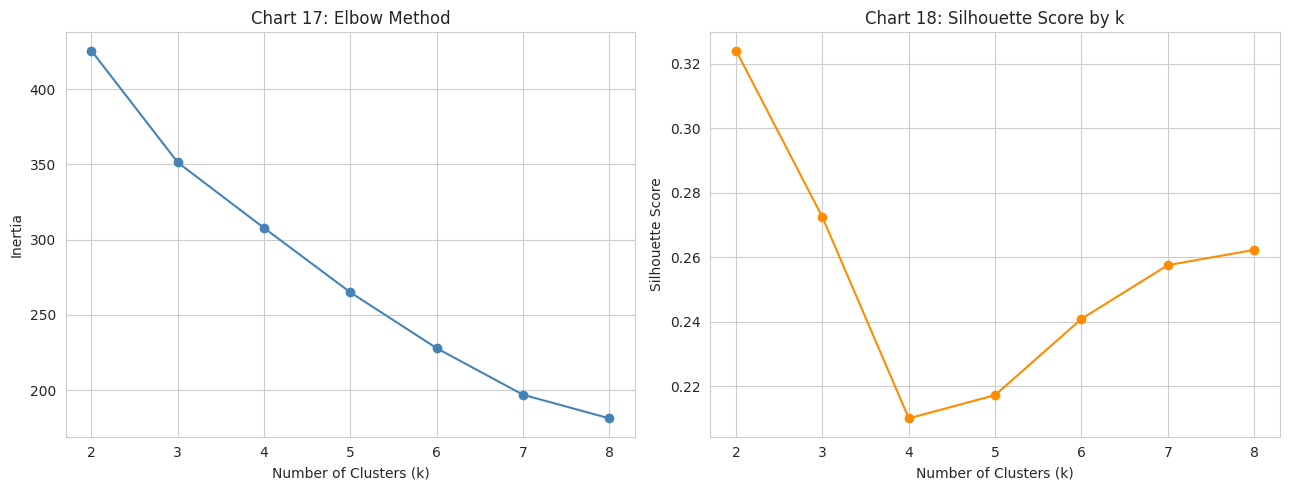

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_title('Chart 17: Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='o', color='darkorange')
axes[1].set_title('Chart 18: Silhouette Score by k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

**Reading the two charts honestly:**
- The **elbow** bends noticeably around **k=3-4** — inertia drops fast up to there, then
  slows down.
- The **silhouette score** is actually *highest at k=2* (~0.32). But k=2 turns out to just
  split restaurants into "expensive" vs. "cheap" — a real pattern, but too coarse to be a
  useful *segmentation* for business decisions. **k=3** has the next-best silhouette (~0.27)
  and lines up with the elbow bend.

**Our decision: k=3.** This is a case where the purely statistical "best" score (k=2) isn't
the most *useful* choice — a good data scientist balances the metric with what actually
produces meaningful, actionable groups. k=3 gives us three genuinely distinct profiles (shown
below), while k=2 would be almost redundant with just looking at `Cost` alone.

**How to explain this to your mentor:** *"The silhouette score technically peaked at 2
clusters, but that only separated restaurants by price. I chose 3 clusters instead, because
it was the next-best statistically supported option, matched the elbow bend, and produced
three segments that are meaningfully different in more than just price."*


## 15. Training the Final K-Means Model (k=3)

In [ ]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

df['cluster'].value_counts().sort_index()

,count
cluster,
0,30
1,60
2,15


**How cluster assignments were generated:** every restaurant's 6 scaled features were
compared to the 3 final centroids, and each restaurant was assigned to whichever centroid it
was closest to (smallest Euclidean distance). This is the same assignment logic used inside
the training loop — we're just applying the final, settled centroids.


## 16. Final Silhouette Score and Cluster Naming

Before visualizing, we compute the silhouette score for our final k=3 solution (using the
same scaled features used to train the model), and assign each numeric cluster a short,
descriptive label we'll use consistently in every chart and discussion from here on.


In [ ]:
final_silhouette = silhouette_score(X_scaled, df['cluster'])
print(f"Final silhouette score (k=3): {final_silhouette:.3f}")

# Consistent cluster naming used throughout the rest of this notebook
cluster_names = {
    0: 'Mid-Premium / Photogenic',
    1: 'Budget Everyday',
    2: 'Premium & Curated'
}
df['cluster_label'] = df['cluster'].map(cluster_names)

# Fixed colors and display order, reused in every chart below
cluster_colors = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868'}
cluster_order = [1, 0, 2]  # Budget Everyday, Mid-Premium/Photogenic, Premium & Curated

df[['Name', 'cluster', 'cluster_label']].groupby('cluster_label').size()

Final silhouette score (k=3): 0.272


,0
cluster_label,
Budget Everyday,60
Mid-Premium / Photogenic,30
Premium & Curated,15


**Note on the silhouette score (0.272):** this is a moderate, not high, score — clusters are
identifiable but do have some overlap (visible later in the PCA scatter). We reported this
number honestly during model selection rather than treating it as a perfect fit.


## 17. Final Cluster Visualizations

Five visualizations, using the consistent naming and colors defined above. Each interpretation
below is limited strictly to what the numbers show — we avoid any language implying overall
restaurant quality, official Zomato rankings, or a causal explanation for the differences.


### 17.1 Cluster Size Bar Chart

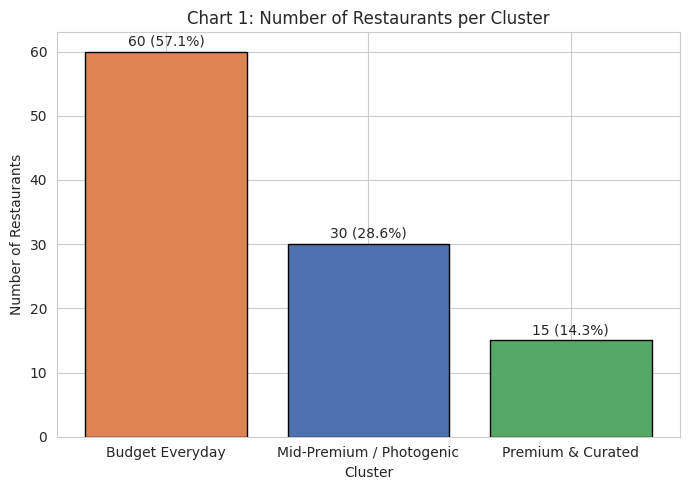

In [ ]:
sizes = df['cluster'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    [cluster_names[c] for c in cluster_order],
    [sizes[c] for c in cluster_order],
    color=[cluster_colors[c] for c in cluster_order],
    edgecolor='k'
)
for bar, c in zip(bars, cluster_order):
    pct = sizes[c] / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{sizes[c]} ({pct:.1f}%)", ha='center', va='bottom', fontsize=10)

ax.set_title('Chart 1: Number of Restaurants per Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()

**Interpretation:** Budget Everyday accounts for 60 restaurants (57.1% of the dataset),
Mid-Premium / Photogenic for 30 (28.6%), and Premium & Curated for 15 (14.3%). The three
clusters are unequal in size, with Budget Everyday roughly 4 times larger than Premium &
Curated.


### 17.2 Cluster-wise Feature Comparison

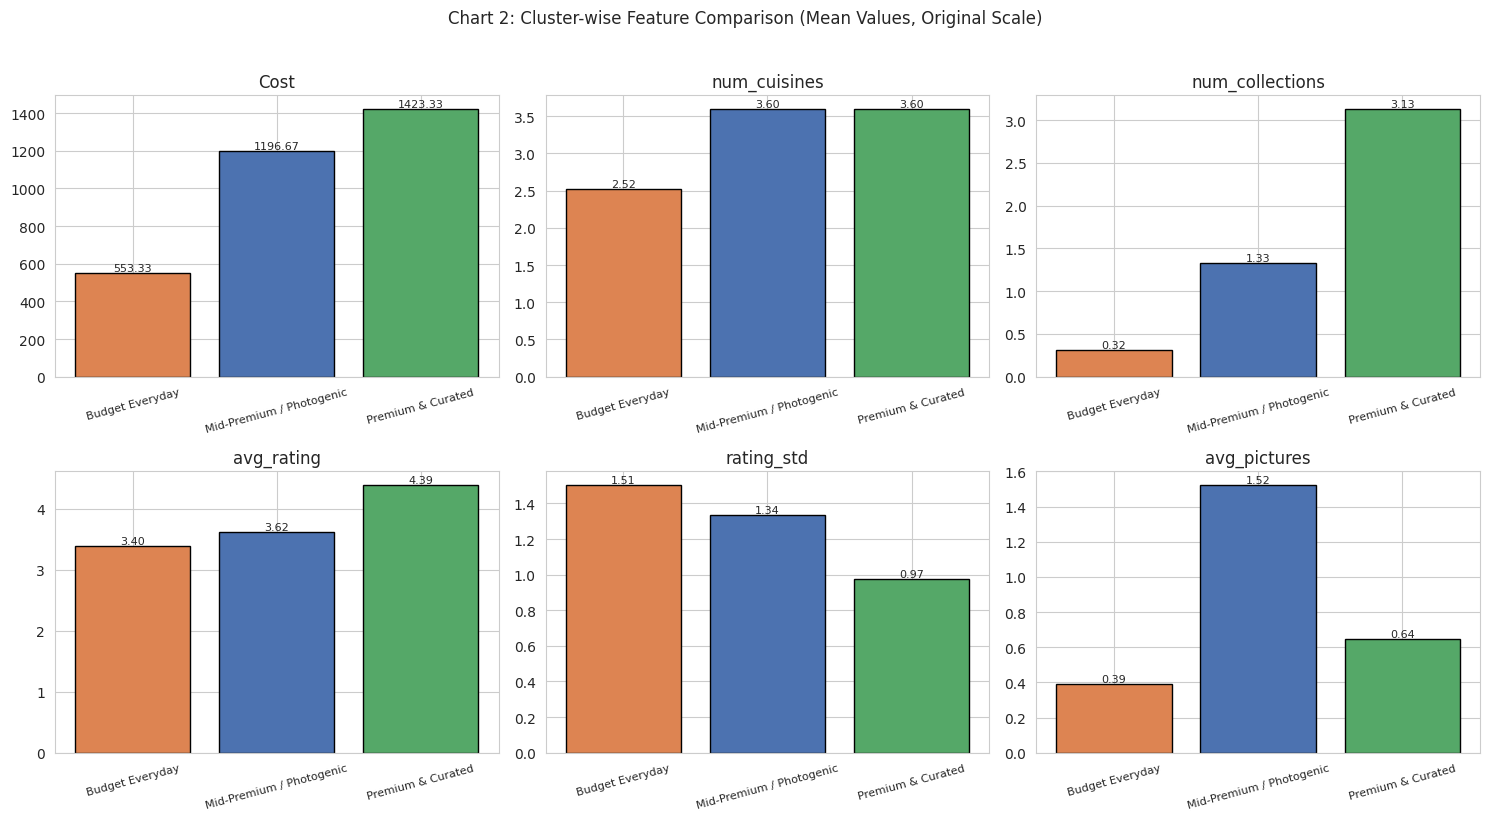

In [ ]:
means = df.groupby('cluster')[feature_cols].mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), feature_cols):
    vals = [means.loc[c, feat] for c in cluster_order]
    bars = ax.bar([cluster_names[c] for c in cluster_order], vals,
                  color=[cluster_colors[c] for c in cluster_order], edgecolor='k')
    ax.set_title(feat)
    ax.tick_params(axis='x', rotation=15, labelsize=8)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.2f}",
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Chart 2: Cluster-wise Feature Comparison (Mean Values, Original Scale)', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** `Cost` and `num_collections` increase in a stepped pattern from Budget
Everyday to Mid-Premium/Photogenic to Premium & Curated (Cost: 553 -> 1197 -> 1423;
collections: 0.32 -> 1.33 -> 3.13). `num_cuisines` is close between Mid-Premium/Photogenic
(3.60) and Premium & Curated (3.60), with Budget Everyday lower (2.52). `avg_pictures` is
highest in Mid-Premium/Photogenic (1.52), not in Premium & Curated (0.64) or Budget Everyday
(0.39). `rating_std` decreases from Budget Everyday (1.51) to Mid-Premium/Photogenic (1.34) to
Premium & Curated (0.97) — this is a numeric fact about how spread out ratings are within each
cluster, not a claim about which cluster is better.


### 17.3 PCA Scatter Plot

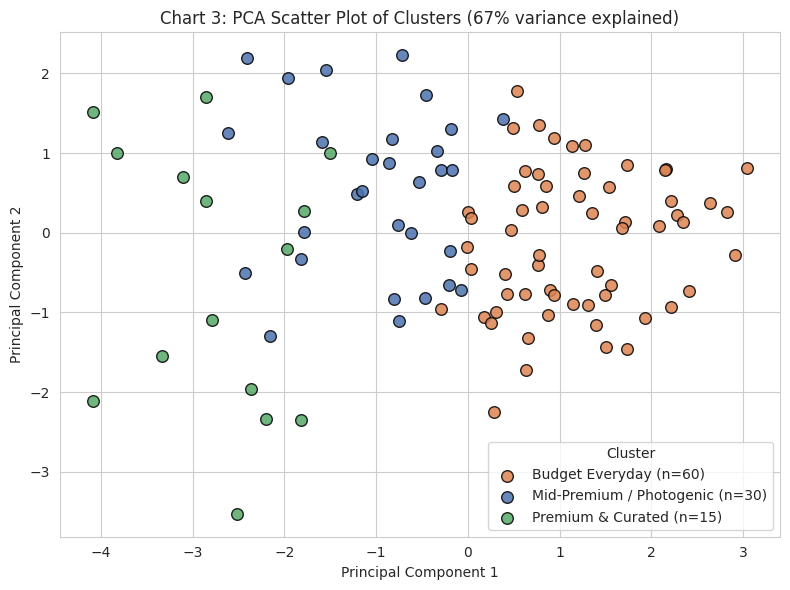

In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
df['pca_1'], df['pca_2'] = pca_coords[:, 0], pca_coords[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
for c in cluster_order:
    sub = df[df['cluster'] == c]
    ax.scatter(sub['pca_1'], sub['pca_2'], label=f"{cluster_names[c]} (n={len(sub)})",
               color=cluster_colors[c], s=70, edgecolor='k', alpha=0.85)

ax.set_title(f'Chart 3: PCA Scatter Plot of Clusters ({pca.explained_variance_ratio_.sum():.0%} variance explained)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

**Interpretation:** the two principal components retain 67% of the original variance. The
three clusters occupy different regions of the plot rather than forming one undifferentiated
cloud: Premium & Curated points sit toward the left/lower-left, Budget Everyday spans the
right-hand side, and Mid-Premium/Photogenic sits centrally with a wider vertical spread. Some
points sit near cluster boundaries, which is expected in real-world data and consistent with
the moderate (0.272) silhouette score.


### 17.4 Boxplots for the Six Clustering Features

In [ ]:
df['cluster_label_ordered'] = pd.Categorical(
    df['cluster_label'],
    categories=[cluster_names[c] for c in cluster_order],
    ordered=True
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.flatten(), feature_cols):
    sns.boxplot(
        x='cluster_label_ordered', y=feat, data=df,
        hue='cluster_label_ordered',
        palette={cluster_names[c]: cluster_colors[c] for c in cluster_order},
        legend=False, ax=ax
    )
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Chart 4: Distribution of Each Clustering Feature by Cluster', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** confirms the direction of each mean difference from Chart 2 while also
showing spread and outliers. For example, `Cost` for Premium & Curated ranges roughly
₹800-1750 (with one ₹2500 outlier), versus Budget Everyday's tighter ₹150-1100 range. The
`rating_std` boxes for the three clusters show limited overlap in their middle 50% (Budget
Everyday roughly 1.2-1.6, Premium & Curated roughly 0.8-1.2), indicating the difference seen
in Chart 2 is not driven by just one or two restaurants.


### 17.5 Standardized Cluster-Profile Heatmap

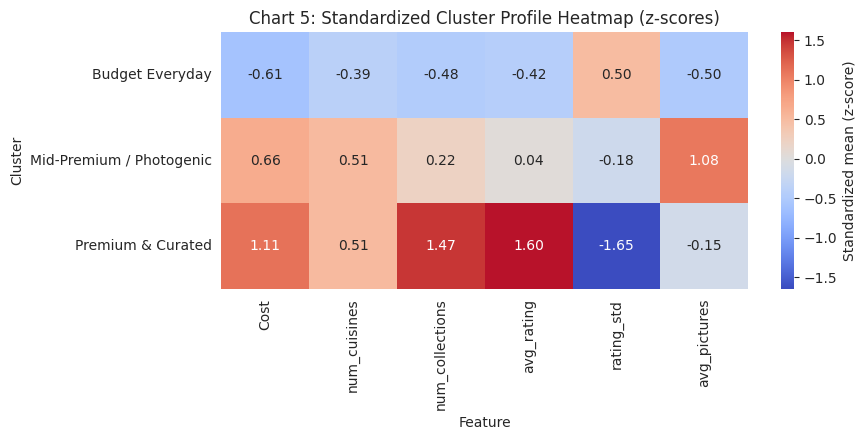

In [ ]:
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df['cluster'] = df['cluster'].values
scaled_means = X_scaled_df.groupby('cluster')[feature_cols].mean()
scaled_means.index = [cluster_names[c] for c in scaled_means.index]
scaled_means = scaled_means.loc[[cluster_names[c] for c in cluster_order]]

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(scaled_means, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Standardized mean (z-score)'}, ax=ax)
ax.set_title('Chart 5: Standardized Cluster Profile Heatmap (z-scores)')
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

**Interpretation:** each cell shows a cluster's average distance from the overall dataset mean,
in standard deviations (0 = dataset average). Premium & Curated is furthest above average on
`avg_rating` (+1.60) and `num_collections` (+1.47), and furthest below average on `rating_std`
(-1.65). Mid-Premium/Photogenic is furthest above average on `avg_pictures` (+1.08) and is the
cluster closest to the dataset average on `avg_rating` (+0.04). Budget Everyday is below the
dataset average on every feature except `rating_std`, where it is above average (+0.50). These
are descriptive positions relative to this dataset's own average, not judgments about
restaurant quality.


## 18. Comparing with Hierarchical Clustering (Sanity Check)

**Is another algorithm worth trying?** Hierarchical clustering can be a useful sanity check
because it doesn't rely on randomly-initialized centroids the way K-Means does. We're **not**
switching our final model to it — just checking whether the 3-cluster structure holds up
under a different clustering algorithm.

We deliberately skip DBSCAN here: DBSCAN is built for finding oddly-shaped clusters and noise
points in dense spatial data, which isn't a good match for our small (105-row), fairly
continuous business-metrics dataset — it would likely just label everything as one cluster or
mark too many restaurants as "noise."


In [ ]:
from sklearn.metrics import adjusted_rand_score

hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

agreement = adjusted_rand_score(df['cluster'], hc_labels)
print(f"Adjusted Rand Index between K-Means and Hierarchical Clustering: {agreement:.2f}")
print("(1.0 = identical clustering, 0.0 = no better than random agreement)")

Adjusted Rand Index between K-Means and Hierarchical Clustering: 0.44
(1.0 = identical clustering, 0.0 = no better than random agreement)


**Interpretation:** the Adjusted Rand Index of 0.44 indicates moderate agreement between
K-Means and Hierarchical Clustering. This provides additional evidence that the grouping is
not entirely dependent on the choice of clustering algorithm.


## 19. Business Observations

These observations describe patterns found in this specific dataset (105 restaurants). They
are correlational, not causal, and are not claims about official Zomato rankings or about
overall restaurant quality.

1. **Budget Everyday** is the largest segment, accounting for 57.1% of the restaurants
   (60 of 105). It has the lowest average rating and the highest rating variability among the
   three clusters. This cluster shows lower values across several observed indicators,
   including average rating, collections, and average pictures, while also having the highest
   rating variability — a pattern worth further investigation, not an explanation of its
   cause.

2. **Mid-Premium / Photogenic** has the highest average picture count (1.52) among the three
   clusters, suggesting greater visual content or photo engagement in the available data. Its
   average rating is moderate at 3.62, with rating variability of 1.34. Photo engagement and
   average rating do not move together in this cluster the way they do in Premium & Curated.

3. **Premium & Curated** has the highest average cost (₹1,423), the highest average number of
   collections (3.13), the highest average rating (4.39), and the lowest rating variability
   (0.97) among the three clusters. Premium & Curated restaurants represent a smaller,
   higher-cost segment with stronger observed rating metrics and greater representation in
   Zomato collections. This is an association between curation, price, and these particular
   rating statistics *within this dataset* — it does not establish that curation causes higher
   ratings, or the reverse.

4. **Collections vs. rating relationship (from earlier EDA):** `num_collections` and
   `avg_rating` were only moderately correlated (+0.36) across the full dataset, meaning
   collection membership and average rating are related but do not fully track each other.

5. **Scope caveat:** these three clusters describe the 105 restaurants in this dataset, which
   appears to be a single city/region with reviews collected up to a specific point in time.
   The clusters should not be assumed to generalize to Zomato's full or current restaurant
   base without re-running this analysis on fresh data.


## 20. Saving the Final Model

We save the trained K-Means model and the scaler (any new restaurant's raw features must go
through the same scaling before the model can assign a cluster), plus the final labeled
dataset for reference.


In [ ]:
with open('kmeans_zomato_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)

with open('scaler_zomato.pkl', 'wb') as f:
    pickle.dump(scaler, f)

df.to_csv('zomato_clustered_restaurants.csv', index=False)

print("Saved: kmeans_zomato_model.pkl, scaler_zomato.pkl, zomato_clustered_restaurants.csv")

Saved: kmeans_zomato_model.pkl, scaler_zomato.pkl, zomato_clustered_restaurants.csv


**How to load and reuse this later** (e.g. to assign a new restaurant to a cluster):
```python
with open('kmeans_zomato_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('scaler_zomato.pkl', 'rb') as f:
    scaler = pickle.load(f)

new_restaurant = [[cost, num_cuisines, num_collections, avg_rating, rating_std, avg_pictures]]
new_scaled = scaler.transform(new_restaurant)
predicted_cluster = model.predict(new_scaled)
```


## 21. Final Conclusion

We built an end-to-end unsupervised learning pipeline on real Zomato restaurant data:

- Aggregated ~10,000 reviews to one row per restaurant *before* merging, avoiding row
  duplication bias, then left-joined onto all 105 metadata restaurants.
- Added a `has_reviews` indicator and imputed the 5 no-review restaurants' review-derived
  features using the median of the 100 reviewed restaurants (never zero).
- Engineered 6 clustering features (`Cost`, `num_cuisines`, `num_collections`, `avg_rating`,
  `rating_std`, `avg_pictures`), deliberately excluding `review_count` (near-zero variance)
  and `has_reviews` (kept only as an analysis flag) from the clustering itself.
- Scaled features with StandardScaler, then evaluated k=2 through k=10 with both the Elbow
  Method and Silhouette Score, and compared full cluster profiles for k=3, k=7, and k=8 before
  choosing.
- Selected **k=3**: the second-best silhouette score (0.272, after k=2's 0.324, which merely
  separated restaurants by price), aligned with the elbow's initial bend, and produced three
  robust, non-fragile clusters — unlike k=8, which produced a 3-restaurant cluster.
- Trained the final K-Means model (`random_state=42`, `n_init=10`) and produced 5 visualizations
  (cluster sizes, feature comparison, PCA scatter, boxplots, standardized heatmap), each with
  an interpretation limited to what the numbers directly show.
- Saved the trained model, scaler, and labeled dataset for reuse.

**One-line summary for your internship review:** *"I aggregated review data per restaurant to
avoid bias, selected k=3 for K-Means after comparing it against both a statistically 'better'
k=2 and more granular k=7/k=8 alternatives, and found three data-driven segments that differ
most clearly in price, curation, and rating consistency — while being careful to describe
these as patterns in this dataset rather than universal quality judgments."*


## 22. GitHub-Ready Project Structure

```
zomato-restaurant-clustering/
├── data/
│   ├── Zomato_Restaurant_names_and_Metadata.csv
│   └── Zomato_Restaurant_reviews.csv
├── notebook/
│   └── Zomato_Restaurant_Clustering.ipynb
├── models/
│   ├── kmeans_zomato_model.pkl
│   └── scaler_zomato.pkl
├── outputs/
│   └── zomato_clustered_restaurants.csv
├── README.md
└── requirements.txt
```

**README.md should include:** problem statement, dataset description, methodology summary
(including the k=3 vs. k=2/k=7/k=8 comparison), the 3 cluster profiles, the scope caveat, and
how to run the notebook.

**requirements.txt:**
```
pandas
numpy
matplotlib
seaborn
scikit-learn
```
